# PhysioNet 2026 Feature Explorer

This notebook helps inspect Challenge data layout and model features from `team_code.py`.

What you can do here:
- Set your dataset path once
- View available records and demographics columns
- Inspect expected feature names and groups
- Check available signal channels from EDF files
- Extract and print model-ready features for a sample record

In [1]:
from pathlib import Path
from collections import Counter

import numpy as np
import pandas as pd

from helper_code import (
    DEMOGRAPHICS_FILE,
    PHYSIOLOGICAL_DATA_SUBFOLDER,
    ALGORITHMIC_ANNOTATIONS_SUBFOLDER,
    HEADERS,
    find_patients,
    load_demographics,
    load_signal_data,
    load_rename_rules,
    standardize_channel_names_rename_only,
)
from team_code import (
    extract_demographic_features,
    extract_physiological_features,
    extract_algorithmic_annotations_features,
    DEFAULT_CSV_PATH,
)

## 1) Set your dataset path
Use the root folder that contains `demographics.csv`, `physiological_data/`, and `algorithmic_annotations/`.

In [2]:
DATA_FOLDER = Path('/home/amendoza/datasets/PhysionetCh2026/training_set')

demographics_path = DATA_FOLDER / DEMOGRAPHICS_FILE
print(f'DATA_FOLDER: {DATA_FOLDER}')
print(f'demographics.csv exists: {demographics_path.exists()}')
print(f'channel_table.csv path used by team_code: {DEFAULT_CSV_PATH}')

DATA_FOLDER: /home/amendoza/datasets/PhysionetCh2026/training_set
demographics.csv exists: True
channel_table.csv path used by team_code: /home/amendoza/gitrepos/physionet_challenge_2026/channel_table.csv


## 2) Quick dataset overview

In [3]:
if not demographics_path.exists():
    raise FileNotFoundError(f'Cannot find demographics file at: {demographics_path}')

df_demo = pd.read_csv(demographics_path)
records = find_patients(str(demographics_path))

print(f'Total rows in demographics: {len(df_demo):,}')
print(f'Unique patient/session records: {len(records):,}')
print('\nColumns:')
for c in df_demo.columns:
    print(f'  - {c}')

display(df_demo.head(3))

Total rows in demographics: 622
Unique patient/session records: 622

Columns:
  - SiteID
  - BDSPPatientID
  - CreationTime
  - BidsFolder
  - SessionID
  - Age
  - Sex
  - Race
  - Ethnicity
  - BMI
  - Time_to_Event
  - Cognitive_Impairment
  - Last_Known_Visit_Date
  - Time_to_Last_Visit


,SiteID,BDSPPatientID,CreationTime,BidsFolder,SessionID,Age,Sex,Race,Ethnicity,BMI,Time_to_Event,Cognitive_Impairment,Last_Known_Visit_Date,Time_to_Last_Visit
0,I0002,150001401,2017-06-02 23:45:01,sub-I0002150001401,2,74,Male,White,Not Hispanic,27.28,1232.0,True,2024-02-04 00:00:00,2437
1,I0002,150005420,2019-07-18 22:12:08,sub-I0002150005420,1,72,Male,White,Not Hispanic,33.06,1269.0,True,2024-02-22 00:00:00,1679
2,I0002,150027762,2018-02-07 21:41:52,sub-I0002150027762,2,77,Male,White,Not Hispanic,NaN,1852.0,True,2024-10-01 00:00:00,2427


## 3) Feature dictionary used by `team_code.py`
This section prints human-readable names for each feature dimension.

In [4]:
demographic_feature_names = [
    'age',
    'sex_female', 'sex_male', 'sex_other_unknown',
    'race_asian', 'race_black', 'race_others', 'race_unavailable', 'race_white',
    'bmi',
]

lead_types = ['eeg', 'eog', 'chin', 'leg', 'ecg', 'resp', 'spo2']
per_lead_features = ['std', 'mav', 'zcr', 'rms', 'activity', 'mobility', 'complexity']
physiological_feature_names = [
    f'phys_{lead}_{feat}'
    for lead in lead_types
    for feat in per_lead_features
]

algorithmic_feature_names = [
    'algo_ahi_auto', 'algo_arousal_auto', 'algo_limb_auto',
    'algo_w_pct', 'algo_n1_pct', 'algo_n2_pct', 'algo_n3_pct', 'algo_r_pct', 'algo_efficiency',
    'algo_prob_w_mean', 'algo_prob_n3_mean', 'algo_prob_arous_mean',
]

all_feature_names = demographic_feature_names + physiological_feature_names + algorithmic_feature_names

print(f'Demographic features: {len(demographic_feature_names)}')
print(f'Physiological features: {len(physiological_feature_names)}')
print(f'Algorithmic features: {len(algorithmic_feature_names)}')
print(f'Total expected features: {len(all_feature_names)}')

feature_df = pd.DataFrame({
    'index': np.arange(len(all_feature_names)),
    'feature_name': all_feature_names,
    'group': (
        ['demographic'] * len(demographic_feature_names)
        + ['physiological'] * len(physiological_feature_names)
        + ['algorithmic'] * len(algorithmic_feature_names)
    )
})
display(feature_df)

Demographic features: 10
Physiological features: 49
Algorithmic features: 12
Total expected features: 71


,index,feature_name,group
0,0,age,demographic
1,1,sex_female,demographic
2,2,sex_male,demographic
3,3,sex_other_unknown,demographic
4,4,race_asian,demographic
...,...,...,...
66,66,algo_r_pct,algorithmic
67,67,algo_efficiency,algorithmic
68,68,algo_prob_w_mean,algorithmic
69,69,algo_prob_n3_mean,algorithmic


## 4) Inspect available EDF channels (friendly summary)
This scans a subset of records and shows the most common raw and standardized channels.

In [5]:
rename_rules = load_rename_rules(DEFAULT_CSV_PATH)

N_RECORDS_TO_SCAN = 10
raw_counter = Counter()
std_counter = Counter()

for record in records[:N_RECORDS_TO_SCAN]:
    patient_id = record[HEADERS['bids_folder']]
    site_id = record[HEADERS['site_id']]
    session_id = record[HEADERS['session_id']]

    phys_path = (
        DATA_FOLDER
        / PHYSIOLOGICAL_DATA_SUBFOLDER
        / str(site_id)
        / f'{patient_id}_ses-{session_id}.edf'
    )

    if not phys_path.exists():
        continue

    phys_data, _ = load_signal_data(str(phys_path))
    raw_channels = list(phys_data.keys())
    raw_counter.update(raw_channels)

    rename_map, cols_to_drop = standardize_channel_names_rename_only(raw_channels, rename_rules)
    kept_channels = [rename_map.get(ch, ch.lower()) for ch in raw_channels if ch not in cols_to_drop]
    std_counter.update(kept_channels)

raw_df = pd.DataFrame(raw_counter.items(), columns=['channel', 'count']).sort_values('count', ascending=False)
std_df = pd.DataFrame(std_counter.items(), columns=['standardized_channel', 'count']).sort_values('count', ascending=False)

print(f'Scanned up to {N_RECORDS_TO_SCAN} records')
display(raw_df.head(30))
display(std_df.head(30))

Scanned up to 10 records


,channel,count
0,f3-m2,10
1,f4-m1,10
2,c3-m2,10
4,o1-m2,10
6,e1,10
8,chin,10
7,e2,10
9,ekg,10
10,lat,10
12,npt,10


,standardized_channel,count
0,f3-m2,10
1,f4-m1,10
2,c3-m2,10
4,o1-m2,10
6,e1,10
8,chin1-chin2,10
7,e2,10
9,ecg,10
10,lat,10
12,ptaf,10


## 5) Extract and print features for one sample record

In [6]:
sample = records[0]
patient_id = sample[HEADERS['bids_folder']]
site_id = sample[HEADERS['site_id']]
session_id = sample[HEADERS['session_id']]

demo = load_demographics(str(demographics_path), patient_id, session_id)
demo_feat = extract_demographic_features(demo)

phys_path = (
    DATA_FOLDER
    / PHYSIOLOGICAL_DATA_SUBFOLDER
    / str(site_id)
    / f'{patient_id}_ses-{session_id}.edf'
)
algo_path = (
    DATA_FOLDER
    / ALGORITHMIC_ANNOTATIONS_SUBFOLDER
    / str(site_id)
    / f'{patient_id}_ses-{session_id}_caisr_annotations.edf'
)

if not phys_path.exists():
    raise FileNotFoundError(f'Missing physiological EDF for sample: {phys_path}')
if not algo_path.exists():
    raise FileNotFoundError(f'Missing algorithmic EDF for sample: {algo_path}')

phys_data, phys_fs = load_signal_data(str(phys_path))
algo_data, _ = load_signal_data(str(algo_path))

phys_feat = extract_physiological_features(phys_data, phys_fs)
algo_feat = extract_algorithmic_annotations_features(algo_data)

full_feat = np.hstack([demo_feat, phys_feat, algo_feat])

print(f'Sample patient/session: {patient_id} / {session_id}')
print(f'Feature vector length: {len(full_feat)}')

out_df = pd.DataFrame({
    'feature_name': all_feature_names,
    'value': full_feat,
})
display(out_df)

print('Group means:')
display(
    out_df.assign(group=feature_df['group'])
    .groupby('group', as_index=False)['value']
    .mean()
)

Sample patient/session: sub-I0002150001401 / 2
Feature vector length: 71


,feature_name,value
0,age,74.000000
1,sex_female,0.000000
2,sex_male,1.000000
3,sex_other_unknown,0.000000
4,race_asian,0.000000
...,...,...
66,algo_r_pct,0.033058
67,algo_efficiency,0.792011
68,algo_prob_w_mean,0.290162
69,algo_prob_n3_mean,0.128384


Group means:


,group,value
0,algorithmic,17.019519
1,demographic,10.328000
2,physiological,2153.705535


Opened EDF: sub-I0002150001401_ses-2.edf
Channels found: 19


,channel,n_samples,fs_hz
0,abdominal,10986000,500.0
1,c3-m2,10986000,500.0
2,c4-m1,10986000,500.0
3,chest,10986000,500.0
4,chin,10986000,500.0
5,e1,10986000,500.0
6,e2,10986000,500.0
7,ekg,10986000,500.0
8,f3-m2,10986000,500.0
9,f4-m1,10986000,500.0



Primary channel: 'f3-m2' | fs=500.00 Hz | duration=366.2 min
Overlay added: `stage_caisr` shown as 30-second epoch labels.
Common mapping in this project: 5=W, 4=R, 3=N1, 2=N2, 1=N3 (check your site docs).


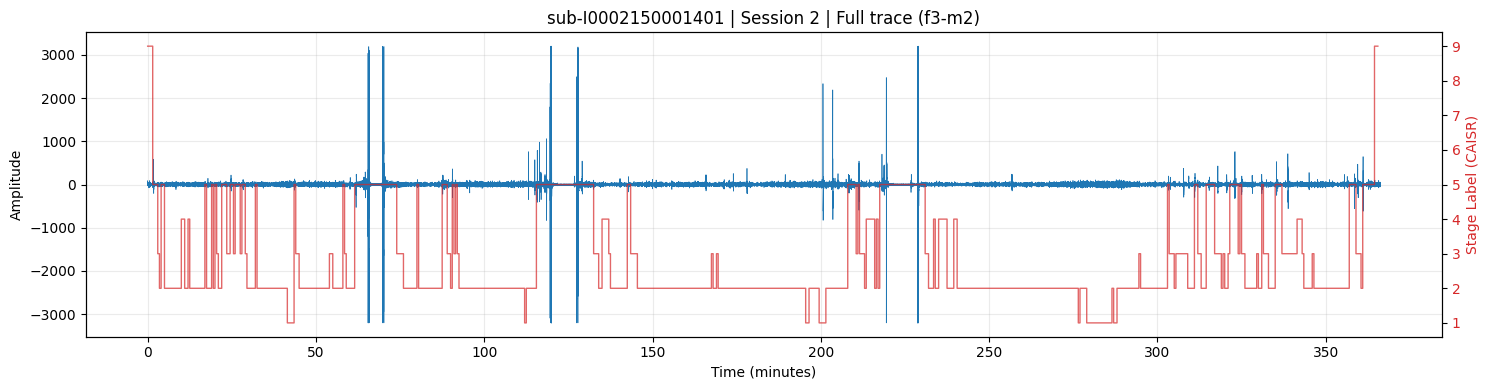


Zoom selection: 115.00-120.00 min
Zoom plot uses 4 physiological signals over 5.0 minutes.
Signals shown: ['f3-m2', 'c3-m2', 'e1', 'e2']


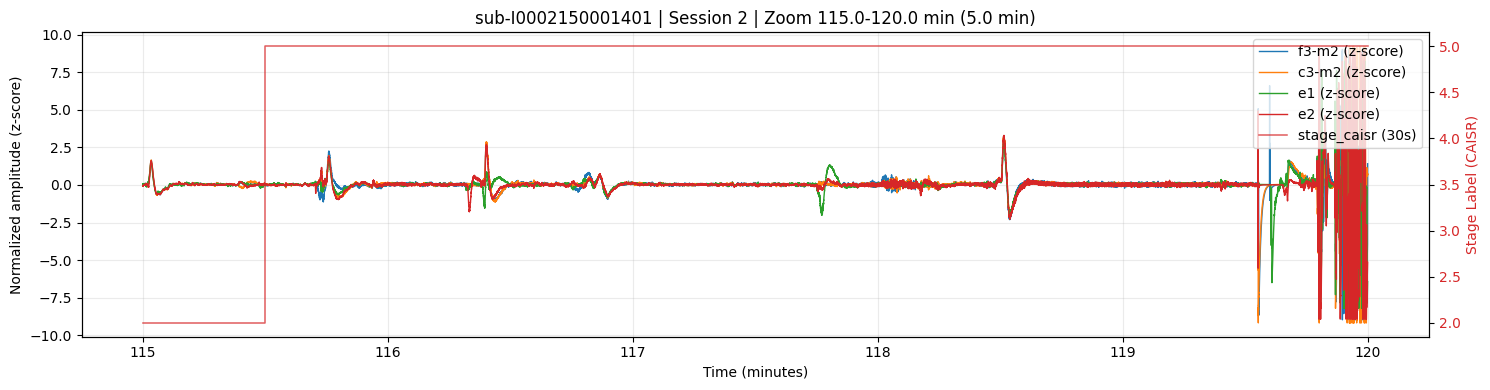

In [9]:
import matplotlib.pyplot as plt



# Pick which record to inspect

RECORD_INDEX = 0



# Zoom settings

ZOOM_DURATION_MIN = 5.0

AUTO_CENTER_ZOOM = True

# Used only if AUTO_CENTER_ZOOM=False

ZOOM_START_MIN = 120.0



if len(records) == 0:

    raise ValueError('No records available. Run the dataset overview cell first.')



rec = records[RECORD_INDEX]

patient_id = rec[HEADERS['bids_folder']]

site_id = rec[HEADERS['site_id']]

session_id = rec[HEADERS['session_id']]



phys_path = (

    DATA_FOLDER

    / PHYSIOLOGICAL_DATA_SUBFOLDER

    / str(site_id)

    / f'{patient_id}_ses-{session_id}.edf'

)

algo_path = (

    DATA_FOLDER

    / ALGORITHMIC_ANNOTATIONS_SUBFOLDER

    / str(site_id)

    / f'{patient_id}_ses-{session_id}_caisr_annotations.edf'

)



if not phys_path.exists():

    raise FileNotFoundError(f'Physiological EDF not found: {phys_path}')



phys_data, phys_fs = load_signal_data(str(phys_path))



print(f'Opened EDF: {phys_path.name}')

print(f'Channels found: {len(phys_data)}')



channel_summary = pd.DataFrame({

    'channel': list(phys_data.keys()),

    'n_samples': [len(phys_data[ch]) for ch in phys_data.keys()],

    'fs_hz': [phys_fs.get(ch, np.nan) for ch in phys_data.keys()],

})

display(channel_summary.sort_values(['fs_hz', 'channel'], ascending=[False, True]).reset_index(drop=True))



# Choose a primary channel to visualize on full timeline

preferred_primary = ['f3-m2', 'c3-m2', 'f4-m1', 'c4-m1', 'e1-m2', 'e2-m1', 'chin1-chin2', 'airflow', 'spo2', 'ecg']

primary_channel = next((ch for ch in preferred_primary if ch in phys_data), list(phys_data.keys())[0])

primary_signal = np.asarray(phys_data[primary_channel]).astype(float)

primary_fs = float(phys_fs[primary_channel])

primary_time_min = np.arange(primary_signal.size) / primary_fs / 60.0



print(f"\nPrimary channel: '{primary_channel}' | fs={primary_fs:.2f} Hz | duration={primary_time_min[-1]:.1f} min")



# --- Plot 1: Full record with stage overlay ---

fig, ax = plt.subplots(figsize=(15, 4))

ax.plot(primary_time_min, primary_signal, linewidth=0.5, color='tab:blue', label=primary_channel)

ax.set_title(f'{patient_id} | Session {session_id} | Full trace ({primary_channel})')

ax.set_xlabel('Time (minutes)')

ax.set_ylabel('Amplitude')

ax.grid(alpha=0.25)



stage_data_available = False

if algo_path.exists():

    algo_data, _ = load_signal_data(str(algo_path))

    if 'stage_caisr' in algo_data and len(algo_data['stage_caisr']) > 0:

        stage_data_available = True

        stage = np.asarray(algo_data['stage_caisr']).astype(float)

        stage_time_min = np.arange(stage.size) * 30.0 / 60.0  # 30-second epochs



        ax2 = ax.twinx()

        ax2.step(stage_time_min, stage, where='post', color='tab:red', alpha=0.7, linewidth=1.0, label='stage_caisr')

        ax2.set_ylabel('Stage Label (CAISR)', color='tab:red')

        ax2.tick_params(axis='y', labelcolor='tab:red')



        print('Overlay added: `stage_caisr` shown as 30-second epoch labels.')

        print('Common mapping in this project: 5=W, 4=R, 3=N1, 2=N2, 1=N3 (check your site docs).')

    else:

        print('No `stage_caisr` channel found in algorithmic EDF; showing physiological signal only.')

else:

    print('Algorithmic annotation EDF not found; showing physiological signal only.')



plt.tight_layout()

plt.show()



# --- Plot 2: 5-minute zoom with multiple overlaid physiological signals ---

record_duration_min = float(primary_time_min[-1])

window_min = min(ZOOM_DURATION_MIN, record_duration_min)



if AUTO_CENTER_ZOOM:

    # Activity score over 5-minute bins using robust spread (95th-5th percentile)

    samples_per_window = max(int(primary_fs * 60.0 * window_min), 1)

    n = len(primary_signal)



    if n <= samples_per_window:

        best_start_idx = 0

    else:

        # Evaluate non-overlapping windows for speed and stability

        starts = np.arange(0, n - samples_per_window + 1, samples_per_window)

        scores = []

        for start in starts:

            seg = primary_signal[start:start + samples_per_window]

            score = np.percentile(seg, 95) - np.percentile(seg, 5)

            scores.append(score)

        best_start_idx = int(starts[int(np.argmax(scores))])



    zoom_start_min = best_start_idx / primary_fs / 60.0

else:

    zoom_start_min = float(ZOOM_START_MIN)



zoom_start_min = max(0.0, min(zoom_start_min, max(record_duration_min - window_min, 0.0)))

zoom_end_min = zoom_start_min + window_min



# Candidate channels to overlay in zoom (first available 4)

overlay_candidates = [

    'f3-m2', 'c3-m2', 'e1', 'e2', 'chin', 'chin1-chin2',

    'airflow', 'npt', 'therm', 'sao2', 'spo2', 'ekg', 'ecg'

]

overlay_channels = [ch for ch in overlay_candidates if ch in phys_data]

if primary_channel not in overlay_channels:

    overlay_channels = [primary_channel] + overlay_channels

overlay_channels = overlay_channels[:4]



fig_zoom, axz = plt.subplots(figsize=(15, 4))

signal_handles = []

signal_labels = []



for ch in overlay_channels:

    sig = np.asarray(phys_data[ch]).astype(float)

    fs_ch = float(phys_fs[ch])

    t_ch_min = np.arange(sig.size) / fs_ch / 60.0



    mask = (t_ch_min >= zoom_start_min) & (t_ch_min <= zoom_end_min)

    if not np.any(mask):

        continue



    t_seg = t_ch_min[mask]

    s_seg = sig[mask]



    # Normalize each signal for shared-axis overlay readability

    seg_std = np.std(s_seg)

    s_seg_norm = (s_seg - np.mean(s_seg)) / (seg_std + 1e-8)



    h, = axz.plot(t_seg, s_seg_norm, linewidth=1.0, label=f'{ch} (z-score)')

    signal_handles.append(h)

    signal_labels.append(f'{ch} (z-score)')



axz.set_title(

    f'{patient_id} | Session {session_id} | Zoom {zoom_start_min:.1f}-{zoom_end_min:.1f} min ({window_min:.1f} min)'

)

axz.set_xlabel('Time (minutes)')

axz.set_ylabel('Normalized amplitude (z-score)')

axz.grid(alpha=0.25)



legend_handles = list(signal_handles)

legend_labels = list(signal_labels)



if stage_data_available:

    stage_mask = (stage_time_min >= zoom_start_min) & (stage_time_min <= zoom_end_min)

    if np.any(stage_mask):

        axz2 = axz.twinx()

        stage_zoom_t = stage_time_min[stage_mask]

        stage_zoom_y = stage[stage_mask]

        h_stage, = axz2.step(stage_zoom_t, stage_zoom_y, where='post', color='tab:red', alpha=0.75, linewidth=1.1)

        axz2.set_ylabel('Stage Label (CAISR)', color='tab:red')

        axz2.tick_params(axis='y', labelcolor='tab:red')

        legend_handles.append(h_stage)

        legend_labels.append('stage_caisr (30s)')



if legend_handles:

    axz.legend(legend_handles, legend_labels, loc='upper right', frameon=True)



print(f"\nZoom selection: {zoom_start_min:.2f}-{zoom_end_min:.2f} min")

print(f"Zoom plot uses {len(signal_handles)} physiological signals over {window_min:.1f} minutes.")

print(f"Signals shown: {[lbl.replace(' (z-score)', '') for lbl in signal_labels]}")



plt.tight_layout()

plt.show()


## 6) Open and visualize an algorithmic annotation EDF
This example loads one `*_caisr_annotations.edf` file and plots all available channels over time.

Opened algorithmic EDF: sub-I0002150001401_ses-2_caisr_annotations.edf
Number of channels: 11


,channel,n_samples,fs_hz
0,arousal_caisr,43920,2.000000
1,caisr_prob_arous,43920,2.000000
2,caisr_prob_no-ar,43920,2.000000
3,limb_caisr,21960,1.000000
4,resp_caisr,21960,1.000000
5,caisr_prob_n1,732,0.033333
6,caisr_prob_n2,732,0.033333
7,caisr_prob_n3,732,0.033333
8,caisr_prob_r,732,0.033333
9,caisr_prob_w,732,0.033333


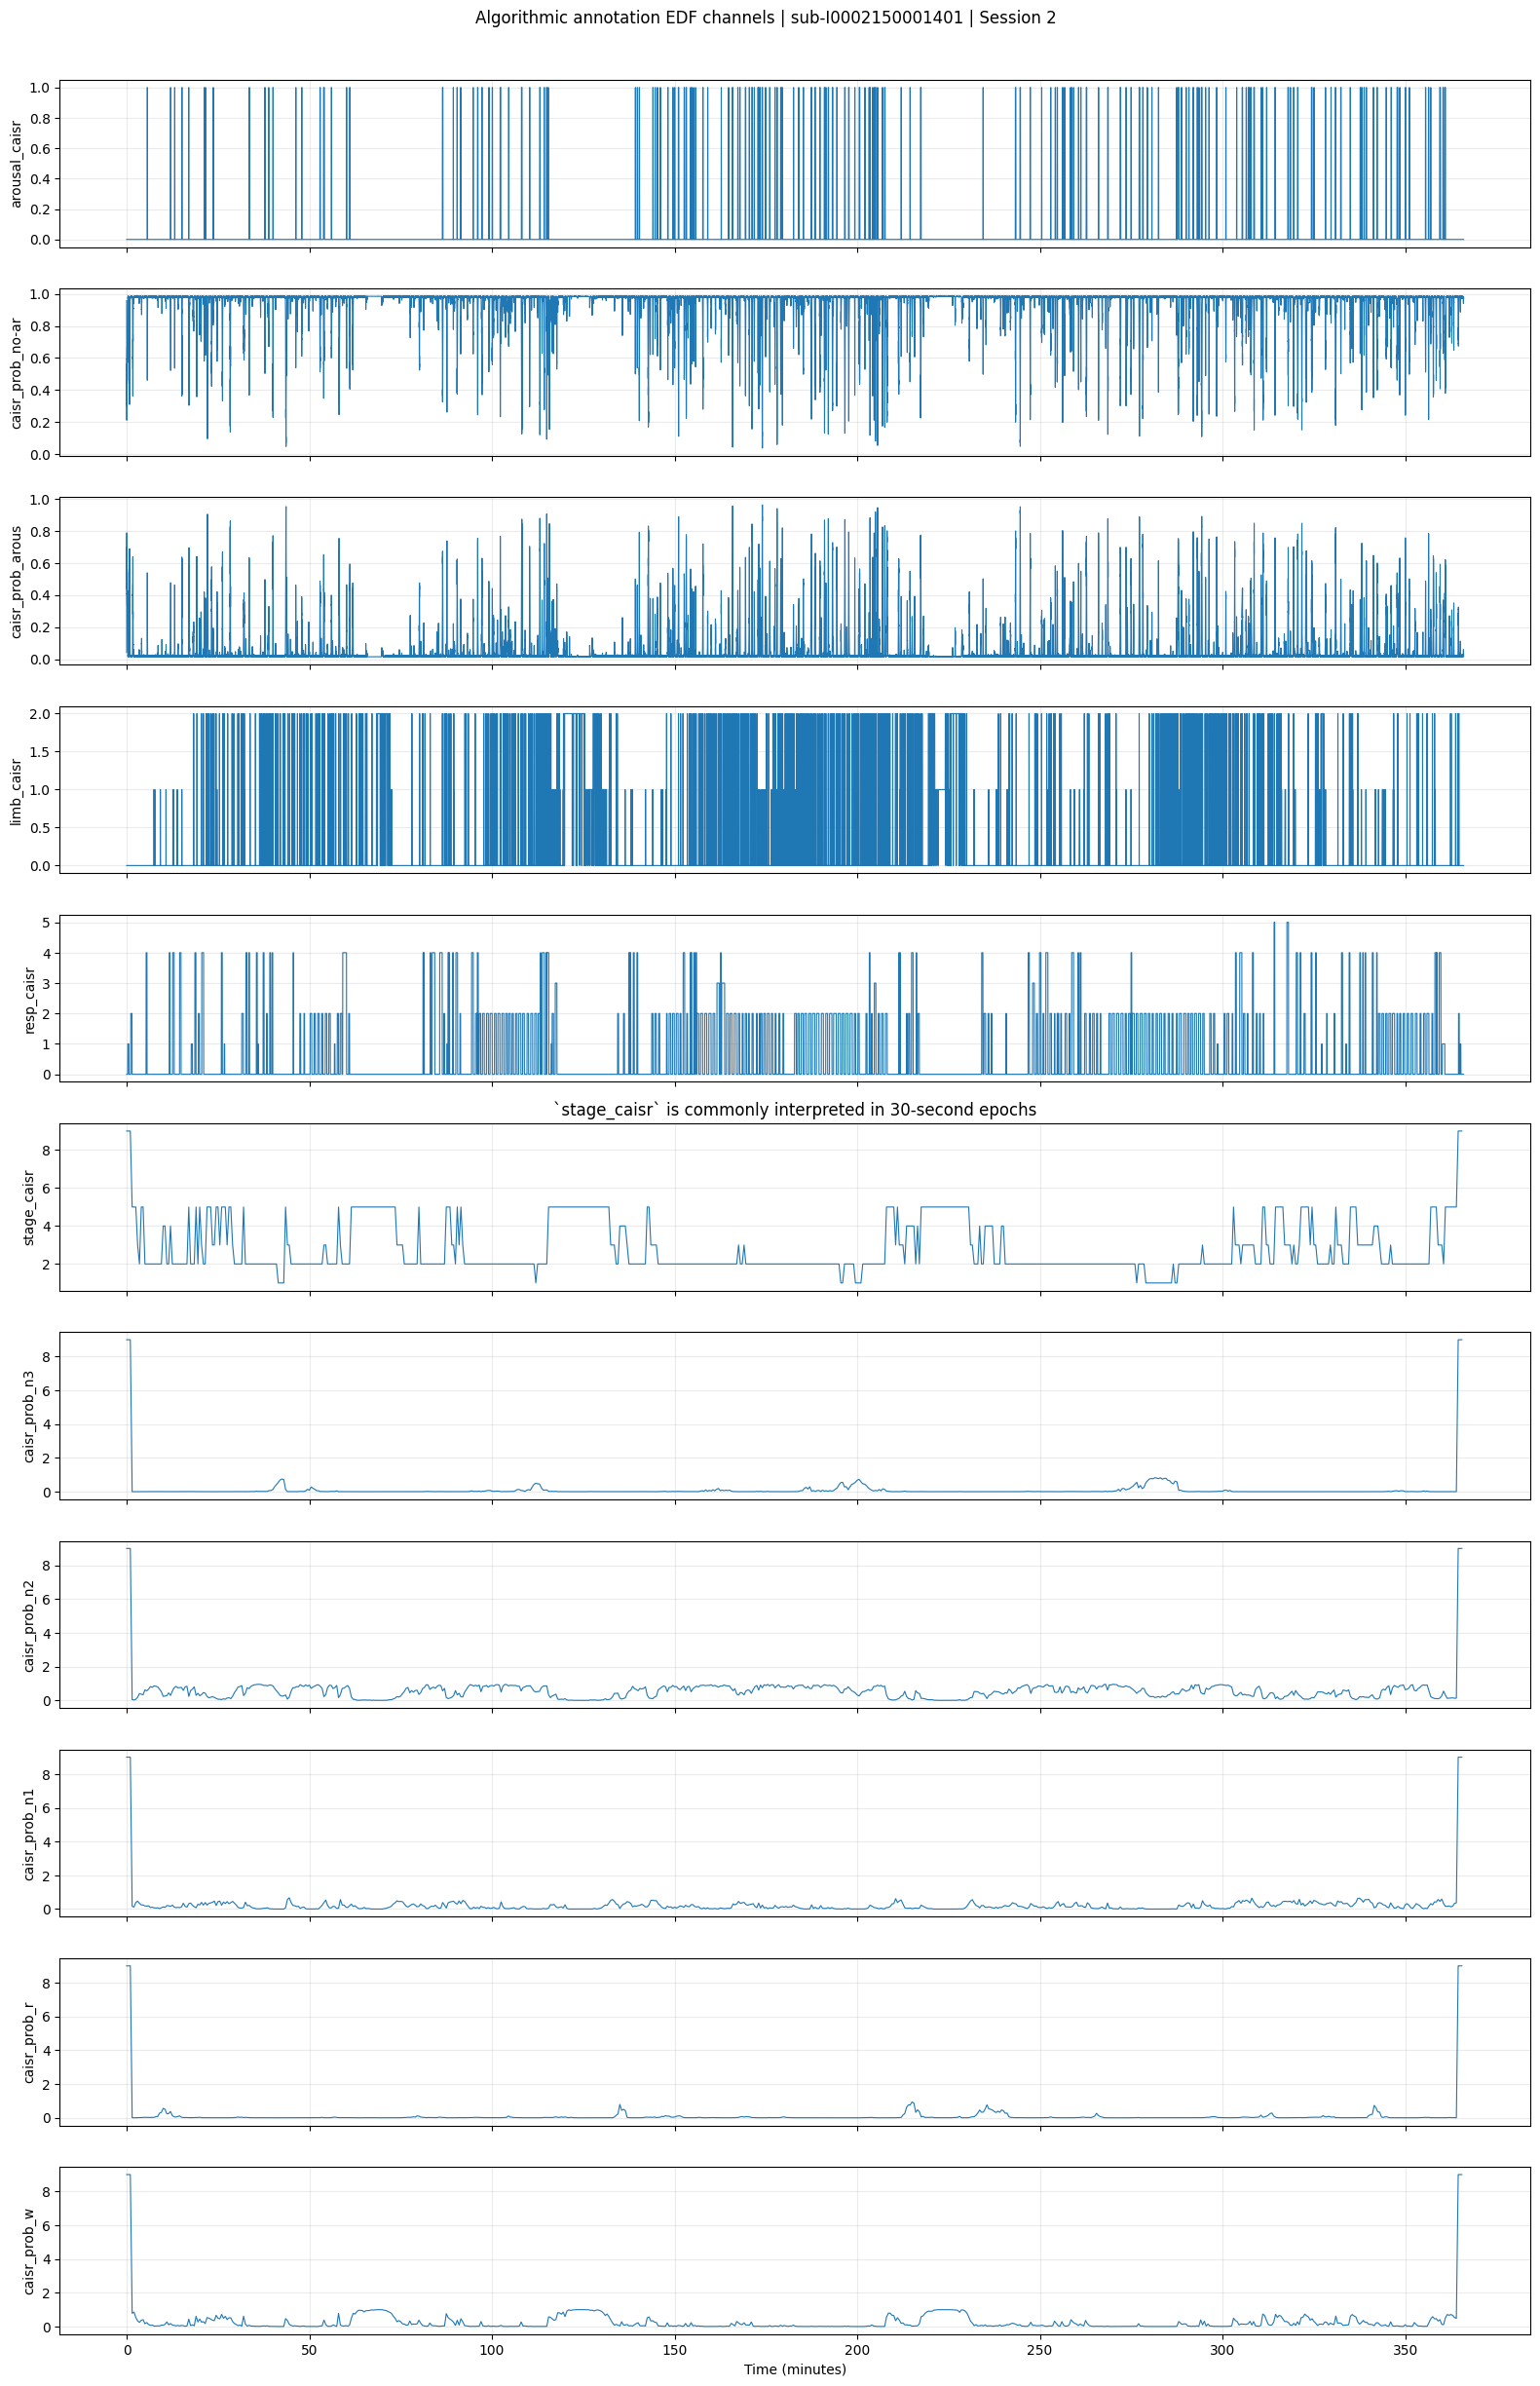

In [10]:
# Select a record (same indexing as previous cells)

ALGO_RECORD_INDEX = RECORD_INDEX if 'RECORD_INDEX' in globals() else 0



if len(records) == 0:

    raise ValueError('No records available. Run the dataset overview cell first.')



algo_rec = records[ALGO_RECORD_INDEX]

algo_patient_id = algo_rec[HEADERS['bids_folder']]

algo_site_id = algo_rec[HEADERS['site_id']]

algo_session_id = algo_rec[HEADERS['session_id']]



algo_example_path = (

    DATA_FOLDER

    / ALGORITHMIC_ANNOTATIONS_SUBFOLDER

    / str(algo_site_id)

    / f'{algo_patient_id}_ses-{algo_session_id}_caisr_annotations.edf'

)



if not algo_example_path.exists():

    raise FileNotFoundError(f'Algorithmic annotation EDF not found: {algo_example_path}')



algo_channels, algo_fs = load_signal_data(str(algo_example_path))

algo_channel_names = list(algo_channels.keys())



print(f'Opened algorithmic EDF: {algo_example_path.name}')

print(f'Number of channels: {len(algo_channel_names)}')



algo_summary_df = pd.DataFrame({

    'channel': algo_channel_names,

    'n_samples': [len(algo_channels[ch]) for ch in algo_channel_names],

    'fs_hz': [algo_fs.get(ch, np.nan) for ch in algo_channel_names],

})

display(algo_summary_df.sort_values(['fs_hz', 'channel'], ascending=[False, True]).reset_index(drop=True))



# Plot each channel in its own row for readability

n_ch = len(algo_channel_names)

fig, axes = plt.subplots(n_ch, 1, figsize=(16, max(2.2 * n_ch, 4)), sharex=True)

if n_ch == 1:

    axes = [axes]



for ax, ch in zip(axes, algo_channel_names):

    y = np.asarray(algo_channels[ch]).astype(float)

    fs_ch = float(algo_fs.get(ch, 1.0))

    t_min = np.arange(y.size) / fs_ch / 60.0



    ax.plot(t_min, y, linewidth=0.8)

    ax.set_ylabel(ch)

    ax.grid(alpha=0.25)



    # Call out expected epoch spacing for stage signals

    if ch == 'stage_caisr':

        ax.set_title('`stage_caisr` is commonly interpreted in 30-second epochs')



axes[-1].set_xlabel('Time (minutes)')

fig.suptitle(f'Algorithmic annotation EDF channels | {algo_patient_id} | Session {algo_session_id}', y=1.01)

plt.tight_layout()

plt.show()
